# Resampling Methods

Resampling methods let us do more with the data we already have. The core idea is to repeatedly draw samples from our training set, fit a model on each one, and use the results to better understand how the model will perform on new data. We'll cover two techniques: **Cross-Validation**, which helps us evaluate how well a model generalizes beyond the data it was trained on, and **Bootstrapping**, which helps us quantify the uncertainty in any estimate when we can't simply go collect more data.

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sklearn.linear_model as skl_lm
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, LeaveOneOut, KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures

import statsmodels.formula.api as smf
import statsmodels.api as sm

In [3]:
url1 = 'https://raw.githubusercontent.com/dsahota-applied-data-analysis/data/main/Auto.csv'
auto = pd.read_csv(url1, na_values='?').dropna()
auto.info()
auto = auto[['mpg', 'horsepower']]

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
 8   name          392 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 30.6+ KB


In [4]:
auto.head()

,mpg,horsepower
0,18.0,130.0
1,15.0,165.0
2,18.0,150.0
3,16.0,150.0
4,17.0,140.0


In [5]:
auto.mpg.mean()

23.445918367346938

### The Validation Set Approach

The simplest approach: randomly split the data into a **training set** and a **validation set**. Fit the model on the training set, then measure error on the validation set. This has two problems. First, the error estimate is unstable — a different random split gives a different answer. Second, because we're only training on part of the data, we tend to overestimate how bad the model really is on truly new data.

The three approaches differ in how they divide the data into training and validation pieces. The diagram below shows this schematically for a dataset of 10 observations — each row is one model fit, and red bars show the held-out validation set.

<BarContainer object of 10 artists>

Text(0.5, 1.0, 'Validation Set Approach — 1 fit, 1 estimate')

(0.0, 10.0)

[]

[]

...

Text(0.5, 1.0, '5-Fold CV — 5 fits, one per fold')

(0.0, 10.0)

[]

[]

Text(0.5, 0.98, 'Cross-Validation Strategies (each row = one model fit; red = held-out validation)')

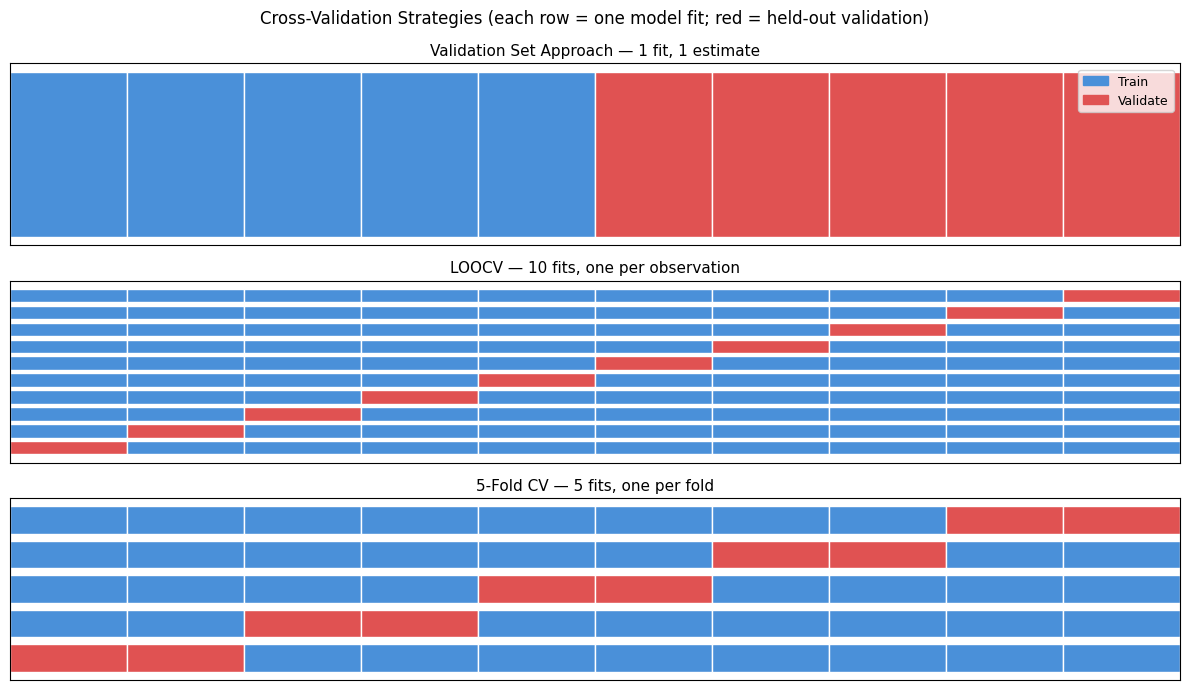

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7))
n = 10
from matplotlib.patches import Patch

# --- Validation Set (single split) ---
mid = n // 2
colors_vs = ['#4a90d9' if i < mid else '#e05252' for i in range(n)]
axes[0].barh([0]*n, [1]*n, left=list(range(n)), color=colors_vs, edgecolor='white', height=0.5)
axes[0].set_title('Validation Set Approach — 1 fit, 1 estimate', fontsize=11)
axes[0].set_xlim(0, n); axes[0].set_yticks([]); axes[0].set_xticks([])
axes[0].legend(handles=[Patch(color='#4a90d9', label='Train'), Patch(color='#e05252', label='Validate')],
               loc='upper right', fontsize=9)

# --- LOOCV ---
for fold in range(n):
    colors = ['#e05252' if i == fold else '#4a90d9' for i in range(n)]
    axes[1].barh([fold]*n, [1]*n, left=list(range(n)), color=colors, edgecolor='white', height=0.8)
axes[1].set_title(f'LOOCV — {n} fits, one per observation', fontsize=11)
axes[1].set_xlim(0, n); axes[1].set_yticks([]); axes[1].set_xticks([])

# --- 5-Fold CV ---
k = 5; fold_size = n // k
for fold in range(k):
    colors = ['#e05252' if i // fold_size == fold else '#4a90d9' for i in range(n)]
    axes[2].barh([fold]*n, [1]*n, left=list(range(n)), color=colors, edgecolor='white', height=0.8)
axes[2].set_title(f'5-Fold CV — {k} fits, one per fold', fontsize=11)
axes[2].set_xlim(0, n); axes[2].set_yticks([]); axes[2].set_xticks([])

plt.suptitle('Cross-Validation Strategies (each row = one model fit; red = held-out validation)', fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
X = auto.horsepower
# Generating Polynomial Features
poly = PolynomialFeatures(2)
X_poly = poly.fit_transform(X.values.reshape(-1, 1))

X
print('\n')
poly
print('\n')
X_poly

0      130.0
1      165.0
2      150.0
3      150.0
4      140.0
       ...  
392     86.0
393     52.0
394     84.0
395     79.0
396     82.0
Name: horsepower, Length: 392, dtype: float64

PolynomialFeatures()

array([[1.0000e+00, 1.3000e+02, 1.6900e+04],
       [1.0000e+00, 1.6500e+02, 2.7225e+04],
       [1.0000e+00, 1.5000e+02, 2.2500e+04],
       ...,
       [1.0000e+00, 8.4000e+01, 7.0560e+03],
       [1.0000e+00, 7.9000e+01, 6.2410e+03],
       [1.0000e+00, 8.2000e+01, 6.7240e+03]])

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_poly, auto.mpg,test_size=.5, random_state=0)

In [9]:
# Scikit-Learn Linear Regression
regr = skl_lm.LinearRegression()
regr.fit(X_train, y_train)
pred = regr.predict(X_test)
mse = mean_squared_error(y_test, pred)

LinearRegression()

In [10]:
mse

18.763031346897744

That used `random_state=0` to fix the split. Changing that one number — which controls which observations land in the training set and which land in the validation set — produces a meaningfully different MSE every time. The model hasn’t changed. The data hasn’t changed. Only the split has.

In [11]:
print('  Seed  |  Validation MSE')
print('-' * 26)
for seed in range(10):
    X_tr, X_te, y_tr, y_te = train_test_split(X_poly, auto.mpg, test_size=0.5, random_state=seed)
    r = skl_lm.LinearRegression()
    r.fit(X_tr, y_tr)
    m = mean_squared_error(y_te, r.predict(X_te))
    print(f'{seed:>6}  |  {m:.4f}')

  Seed  |  Validation MSE
--------------------------


LinearRegression()

     0  |  18.7630


LinearRegression()

     1  |  18.8483


...

     7  |  20.0109


LinearRegression()

     8  |  16.3016


LinearRegression()

     9  |  20.7182


### Leave-One-Out Cross Validation (LOOCV)

LOOCV fixes the instability of the validation set approach by doing something more systematic. For each observation, hold that single observation out as the validation set, train on everything else, and record the error. Repeat this for every observation, then average all the errors. The result is deterministic (no randomness) and doesn't overestimate test error the way a single split does. The downside is cost: we fit the model as many times as there are observations, and because all those training sets are nearly identical to each other, the error estimates are highly correlated — which leads to higher variance.

In [12]:
regr = skl_lm.LinearRegression()
loo = LeaveOneOut()
loo.get_n_splits(X_poly)

392

In [13]:
score = cross_val_score(regr, X_poly, auto.mpg, cv=loo, scoring='neg_mean_squared_error').mean()

In [14]:
score

-19.248213124489574

The average mean-squared-error using the LOOCV approach actually performs slightly worse that the Validation set approach. This is because the 392 splits of our data, when juxtaposed, are incredibly similar, leaving our model prone to great variance.

In [15]:
for i in range(1,6):
    score = cross_val_score(regr, PolynomialFeatures(i).fit_transform(X.values.reshape(-1,1)), auto.mpg, cv=loo, \
                        scoring='neg_mean_squared_error').mean()
    print(i, score)

1 -24.231513517929226
2 -19.248213124489574
3 -19.33498406408846
4 -19.424430307307563
5 -19.03320629071331


### Cross-Validation for Classification

Cross-validation works exactly the same way for classification problems — the only difference is what we measure as the error. Instead of mean squared error, we count the fraction of observations that were misclassified.

When evaluating a classifier, a **confusion matrix** is a useful way to break down the results. It's a table that shows four outcomes: **True Positives** (we said yes, it was yes), **False Positives** (we said yes, it was no), **True Negatives** (we said no, it was no), and **False Negatives** (we said no, it was yes). From those four numbers, we can compute several metrics:

- **Recall / Sensitivity**: Of all the actual positives, how many did we catch? (True Positives divided by True Positives plus False Negatives)
- **Precision**: Of all the things we predicted as positive, how many actually were? (True Positives divided by True Positives plus False Positives)
- **Specificity**: Of all the actual negatives, how many did we correctly identify? (True Negatives divided by True Negatives plus False Positives)
- **Accuracy**: Of all predictions, how many were correct? (True Positives plus True Negatives divided by everything)

Which metric matters most depends on the problem — for example, in medical testing you might care more about recall than precision.

### k-Fold Cross-Validation

k-Fold cross-validation is the practical middle ground between the single validation split and LOOCV. Split the data into k roughly equal groups (called folds). Hold one fold out as the validation set, train on the remaining k-1 folds, record the error. Rotate through all k folds as the validation set, then average the k error estimates. LOOCV is actually just k-fold with k equal to the number of observations.

There is a bias-variance tradeoff in the choice of k: larger k means more training data per fold (less bias), but the folds overlap more (higher variance). In practice, k=5 or k=10 works well. A good workflow: use 80% of your data for cross-validation to select the right model complexity, hold out the remaining 20% as a true test set, then fit the final model on the full 80% and evaluate once on the 20%.

In [16]:
kf = KFold(n_splits=10, random_state=0, shuffle=True)
kf.get_n_splits(X_poly)

10

In [17]:
score = cross_val_score(regr, X_poly, auto.mpg, cv=kf, scoring='neg_mean_squared_error').mean()
score

-19.185331419374926

In [18]:
for i in range(1,10):
    score = cross_val_score(regr, PolynomialFeatures(i).fit_transform(X.values.reshape(-1,1)), auto.mpg, cv=kf, \
                        scoring='neg_mean_squared_error').mean()
    print(i, score)

1 -24.20766449017134
2 -19.185331419374926
3 -19.276266655477986
4 -19.478484017804444
5 -19.137196727441342
6 -19.05733981218593
7 -19.25366324808987
8 -19.379194528494565
9 -19.249263931981304


### Comparing LOOCV and k-Fold MSE

Both approaches agree on which polynomial degree is best — the curve bottoms out around degree 2, with diminishing returns after that. Notice that the LOOCV and k-fold curves track each other closely. Both are far more stable than the single-split validation set approach, and they recommend the same model.

Text(0.5, 0, 'Polynomial Degree')

Text(0, 0.5, 'Mean Squared Error')

Text(0.5, 1.0, 'Test MSE vs Polynomial Degree: LOOCV vs 10-Fold CV')

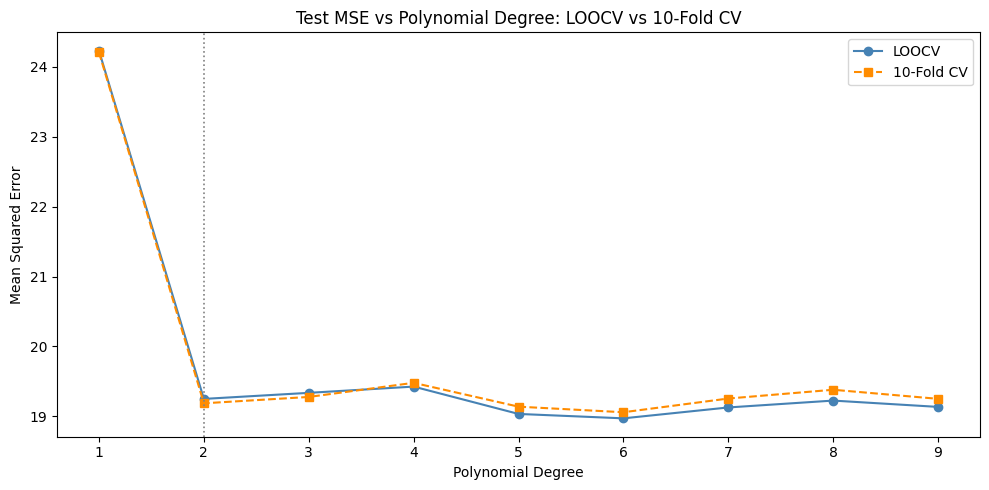

In [19]:
degrees = range(1, 10)
loocv_mse_list = []
kfold_mse_list = []
_regr = skl_lm.LinearRegression()
_X = auto.horsepower

for i in degrees:
    Xp = PolynomialFeatures(i).fit_transform(_X.values.reshape(-1, 1))
    loo_score = -cross_val_score(_regr, Xp, auto.mpg, cv=LeaveOneOut(),
                                 scoring='neg_mean_squared_error').mean()
    kf_score  = -cross_val_score(_regr, Xp, auto.mpg,
                                 cv=KFold(n_splits=10, random_state=0, shuffle=True),
                                 scoring='neg_mean_squared_error').mean()
    loocv_mse_list.append(loo_score)
    kfold_mse_list.append(kf_score)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(degrees, loocv_mse_list, 'o-', color='steelblue', label='LOOCV')
ax.plot(degrees, kfold_mse_list, 's--', color='darkorange', label='10-Fold CV')
ax.set_xlabel('Polynomial Degree')
ax.set_ylabel('Mean Squared Error')
ax.set_title('Test MSE vs Polynomial Degree: LOOCV vs 10-Fold CV')
ax.legend()
ax.set_xticks(list(degrees))
ax.axvline(2, color='gray', linestyle=':', linewidth=1.2, label='Degree 2 (elbow)')
plt.tight_layout()
plt.show()

### Bootstrapping

Bootstrapping addresses a different problem: how do we quantify the uncertainty of an estimate when we can't go collect more data? The trick is to simulate new datasets from the one we already have. We sample from our existing dataset **with replacement** — meaning the same observation can be picked more than once — to create many fake "new" datasets of the same size. We calculate our statistic (a model coefficient, a prediction, whatever we care about) on each fake dataset. The variability of those estimates across all the fake datasets gives us the standard error of our estimate.

The key idea is **sampling with replacement**: each bootstrap sample is drawn from the original data, but any observation can appear more than once, and some observations may not appear at all. We compute our statistic on each bootstrap sample; the spread across those estimates is our standard error.

<BarContainer object of 1 artists>

Text(0.5, 0, '1')

<BarContainer object of 1 artists>

Text(1.5, 0, '2')

<BarContainer object of 1 artists>

...

Text(0.5, 1.0, 'Bootstrap Sample 4  (repeated: obs 4 ×2, obs 5 ×2)')

(0.0, 8.0)

[]

[]

Text(0.5, 0.98, 'Bootstrapping: sample with replacement → estimate variability of any statistic')

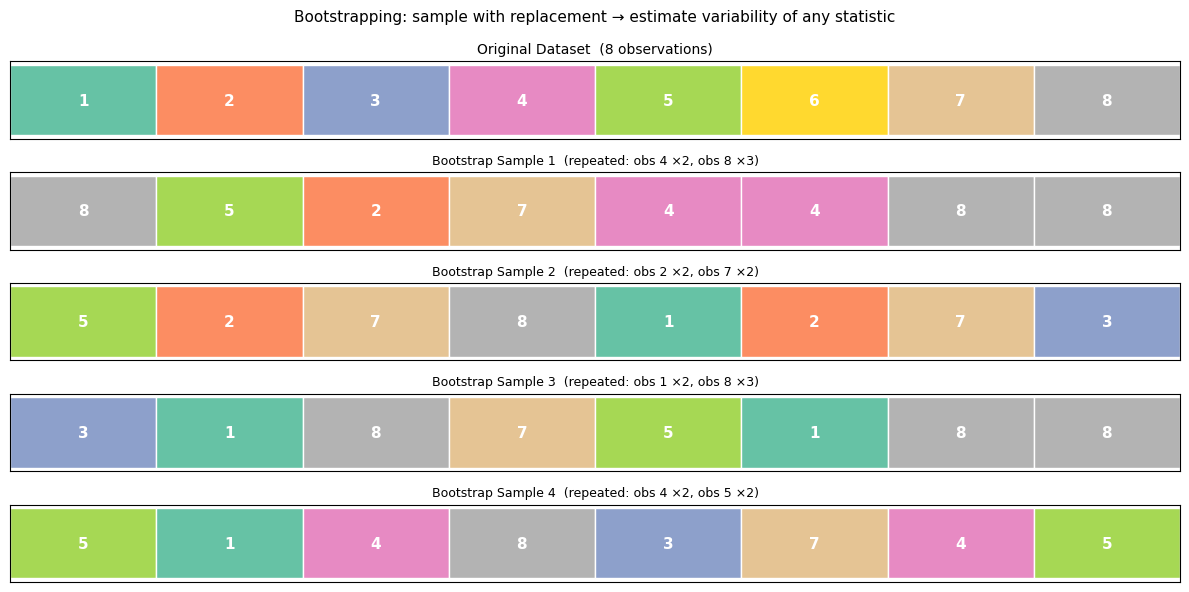

In [20]:
np.random.seed(7)
n_orig = 8
n_boot = 4
orig_idx = np.arange(n_orig)
cmap = plt.cm.Set2(np.linspace(0, 0.9, n_orig))

fig, axes = plt.subplots(1 + n_boot, 1, figsize=(12, 6))

# Original dataset
for j in range(n_orig):
    axes[0].barh(0, 1, left=j, color=cmap[j], edgecolor='white', height=0.6)
    axes[0].text(j + 0.5, 0, str(j + 1), ha='center', va='center',
                 fontsize=11, color='white', fontweight='bold')
axes[0].set_title('Original Dataset  (8 observations)', fontsize=10)
axes[0].set_xlim(0, n_orig); axes[0].set_yticks([]); axes[0].set_xticks([])

for b in range(n_boot):
    samp = np.random.choice(n_orig, n_orig, replace=True)
    for j, idx in enumerate(samp):
        axes[b + 1].barh(0, 1, left=j, color=cmap[idx], edgecolor='white', height=0.6)
        axes[b + 1].text(j + 0.5, 0, str(idx + 1), ha='center', va='center',
                         fontsize=11, color='white', fontweight='bold')
    u, c = np.unique(samp, return_counts=True)
    dups = ', '.join([f'obs {x+1} ×{n}' for x, n in zip(u, c) if n > 1])
    title = f'Bootstrap Sample {b + 1}'
    if dups:
        title += f'  (repeated: {dups})'
    axes[b + 1].set_title(title, fontsize=9)
    axes[b + 1].set_xlim(0, n_orig); axes[b + 1].set_yticks([]); axes[b + 1].set_xticks([])

plt.suptitle('Bootstrapping: sample with replacement → estimate variability of any statistic',
             fontsize=11)
plt.tight_layout()
plt.show()

In [21]:
def alpha(data):
    X = data['X'].values
    Y = data['Y'].values

    # np.cov returns full cov matrix we need [0][1] cov(x,y)
    return (np.var(Y) - np.cov(X,Y)[0][1])/(np.var(X) + np.var(Y) - 2*np.cov(X,Y)[0][1])

In [22]:
url2 = 'https://raw.githubusercontent.com/dsahota-applied-data-analysis/data/main/Portfolio.csv'
portfolio = pd.read_csv(url2)

In [23]:
alpha(portfolio)

0.5766511516664772

Since Scikit-Learn no longer supports Bootstrap, we'll write our own pseudo-bootstrap:

In [24]:
def boot(data, statistic_calculator, num_samples = 1000):
    stat_samples = []
    for sample in range(num_samples):
        # make len(data) random choices of indices WITH REPLACEMENT
        indices = np.random.choice(data.index, len(data), replace=True)
        XY = data.iloc[indices]
        stat_samples.append(statistic_calculator(XY))

    se_estimate = np.std(stat_samples, axis=0, ddof=1)
    print('Bootstrapped Std. Error(s) =', se_estimate)
    return se_estimate

In [25]:
np.random.seed(0)
boot(portfolio, alpha)

Bootstrapped Std. Error(s) = 0.08984902736174315


0.08984902736174315

Now, we apply the Bootstrap method to estimate the accuracy of the intercept and slope coefficients that use horsepower to predict mpg.

In [26]:
auto = pd.read_csv(url1)
auto['horsepower'] = pd.to_numeric(auto.horsepower, errors='coerce')
auto['mpg'] = pd.to_numeric(auto.mpg, errors='coerce')
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


In [27]:
est = smf.ols('mpg ~ horsepower', auto).fit()
est.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,39.9359,0.717,55.660,0.000,38.525,41.347
horsepower,-0.1578,0.006,-24.489,0.000,-0.171,-0.145


This bootstrapper works with any statistic_calculator, so we can write one that returns the coefficients.

In [28]:
def autoparameters(data):
    return smf.ols('mpg ~ horsepower', data).fit().params

In [29]:
autoparameters(auto)

Intercept     39.935861
horsepower    -0.157845
dtype: float64

In [30]:
boot(auto, autoparameters)

Bootstrapped Std. Error(s) = [0.89342356 0.00763536]


array([0.89342356, 0.00763536])

We can also write our own statistic_calculator to return quadratic regression coefficients.

In [31]:
def autoparameters2(data):
    return smf.ols('mpg ~ horsepower + np.square(horsepower)', data).fit().params

In [32]:
autoparameters2(auto)

Intercept                56.900100
horsepower               -0.466190
np.square(horsepower)     0.001231
dtype: float64

In [33]:
boot(auto, autoparameters2)

Bootstrapped Std. Error(s) = [2.05403436e+00 3.27766258e-02 1.18756662e-04]


array([2.05403436e+00, 3.27766258e-02, 1.18756662e-04])